In [34]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.visualization import AsinhStretch, ImageNormalize

image = '../src/cutouts/src_00056.fits'
file = fits.open(image)
sci = file["SCI"].data.astype(float)
err = file["ERR"].data.astype(float)

mean, sky_median, sky_std = sigma_clipped_stats(sci, sigma=3.0)
print(f"sky median = {sky_median:.4f}   sky std = {sky_std:.4f}   peak = {np.nanmax(sci):.4f}")

sky median = 0.0002   sky std = 0.0079   peak = 20.7164


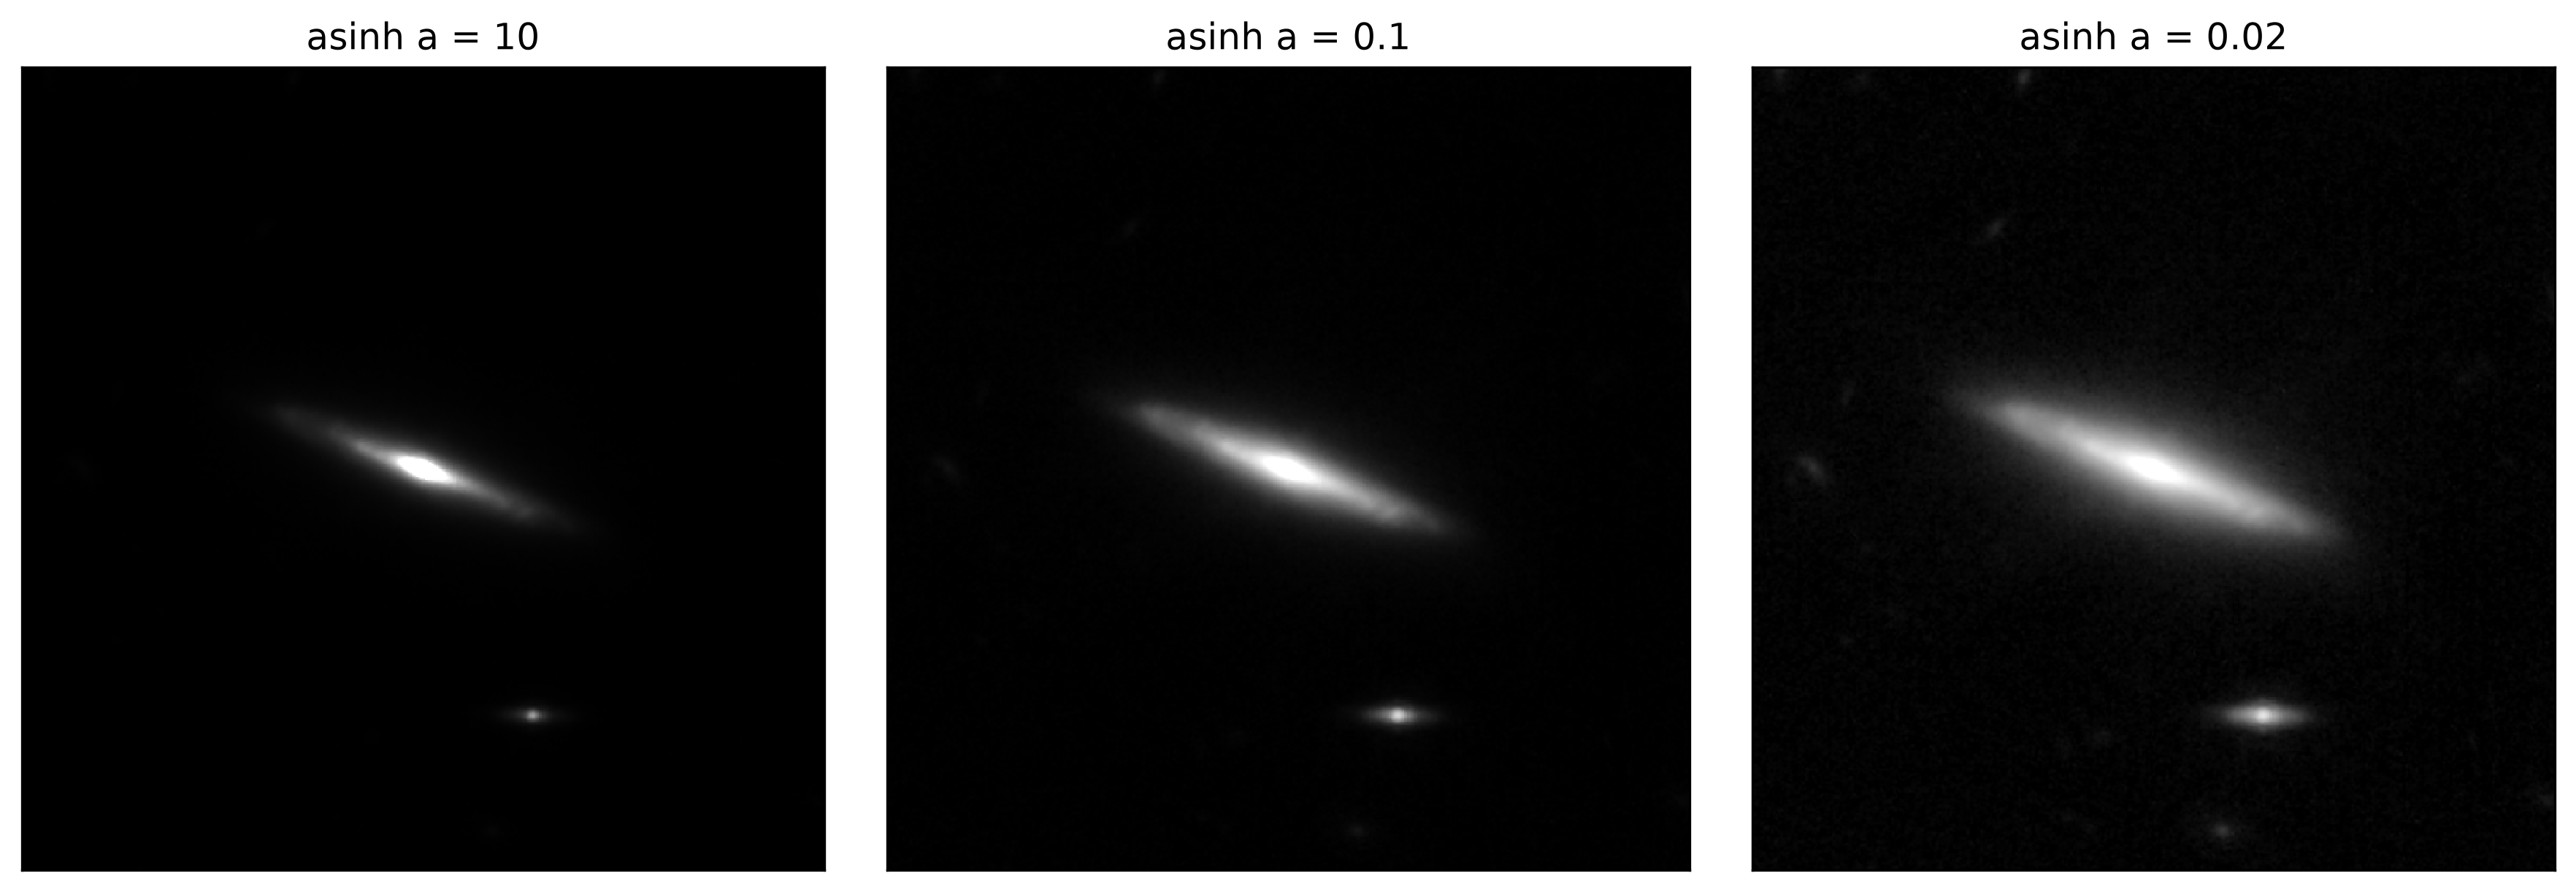

In [35]:
vmin = sky_median - 1.0 * sky_std
vmax = np.nanpercentile(sci, 99.9)

a_values = [10, 0.1, 0.02]
fig, axes = plt.subplots(1, len(a_values), figsize=(4*len(a_values), 4), dpi=300)
for ax, a in zip(axes, a_values):
    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(a=a))
    ax.imshow(sci, origin="lower", cmap="gray", norm=norm, interpolation="nearest")
    ax.set_title(f"asinh a = {a}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()